Cell 1 import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib


cell 2 load and preprocessing

In [2]:
df = pd.read_csv('../data/gempa_1990-2026.csv')
df = df[df['type'] == 'earthquake'].copy()

df['time'] = pd.to_datetime(df['time'])
df['bulan'] = df['time'].dt.month
df['jam']   = df['time'].dt.hour

fitur = ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'nst', 'bulan', 'jam']

for col in ['gap', 'dmin', 'nst']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df_clean = df[fitur].dropna().reset_index(drop=True)

print(f"Total data: {df_clean.shape[0]} baris")


Total data: 63413 baris


cell 3 isolation forest (generate label)

In [3]:
# Split data DULU sebelum fit Isolation Forest — mencegah label leakage
X_raw = df_clean[fitur]

X_train_raw, X_test_raw = train_test_split(
    X_raw, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Eksperimen 3 nilai contamination — IF hanya fit pada train
hasil_if_train = {}
hasil_if_test  = {}
for c in [0.01, 0.05, 0.10]:
    iso = IsolationForest(contamination=c, n_estimators=100, random_state=42)
    iso.fit(X_train_scaled)
    label_train = (iso.predict(X_train_scaled) == -1).astype(int)
    label_test  = (iso.predict(X_test_scaled)  == -1).astype(int)
    hasil_if_train[c] = label_train
    hasil_if_test[c]  = label_test
    print(f"Contamination {c}: train {label_train.sum()} anomali, test {label_test.sum()} anomali")


Contamination 0.01: train 508 anomali, test 130 anomali
Contamination 0.05: train 2537 anomali, test 651 anomali
Contamination 0.1: train 5073 anomali, test 1303 anomali


cell 4 pilih contamination and buat label final

In [4]:
contamination_terpilih = 0.05

y_train = hasil_if_train[contamination_terpilih]
y_test  = hasil_if_test[contamination_terpilih]
X_train = X_train_raw.reset_index(drop=True)
X_test  = X_test_raw.reset_index(drop=True)

print(f"Train — Normal: {(y_train==0).sum()}, Anomali: {(y_train==1).sum()}")
print(f"Test  — Normal: {(y_test==0).sum()},  Anomali: {(y_test==1).sum()}")


Train — Normal: 48193, Anomali: 2537
Test  — Normal: 12032,  Anomali: 651


cell 5 split data

In [5]:
# Split sudah dilakukan di cell 3 (sebelum fit Isolation Forest)
# Ukuran data:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (50730, 8), Test: (12683, 8)


cell 6 tuning XGBoost

In [6]:
# Hapus * 10 — multiplier agresif penyebab confidence 99-100%
scale = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [3, 5, 10],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1, 2, 5],
}

base = XGBClassifier(scale_pos_weight=scale, eval_metric='logloss', random_state=42)
search = RandomizedSearchCV(base, param_grid, n_iter=40, scoring='f1',
                            cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best F1 CV :", round(search.best_score_, 4))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 CV : 0.8828


cell 7 training final dengan early stopping

In [7]:
model = XGBClassifier(**search.best_params_, scale_pos_weight=scale,
                      eval_metric='aucpr', early_stopping_rounds=20, random_state=42)
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=False)

print(f"Best iteration: {model.best_iteration}")


Best iteration: 295


cell 8 evaluasi lengkap

In [8]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_train = model.predict(X_train)

print("Accuracy (train) :", round(accuracy_score(y_train, y_pred_train), 4))
print("Accuracy (test)  :", round(accuracy_score(y_test, y_pred), 4))
print("Precision        :", round(precision_score(y_test, y_pred, pos_label=1), 4))
print("Recall Anomali   :", round(recall_score(y_test, y_pred, pos_label=1), 4))
print("F1 Anomali       :", round(f1_score(y_test, y_pred, pos_label=1), 4))
print("AUC-ROC          :", round(roc_auc_score(y_test, y_proba), 4))


Accuracy (train) : 0.995
Accuracy (test)  : 0.986
Precision        : 0.8141
Recall Anomali   : 0.9416
F1 Anomali       : 0.8732
AUC-ROC          : 0.9981


cell 9 confusion matrix

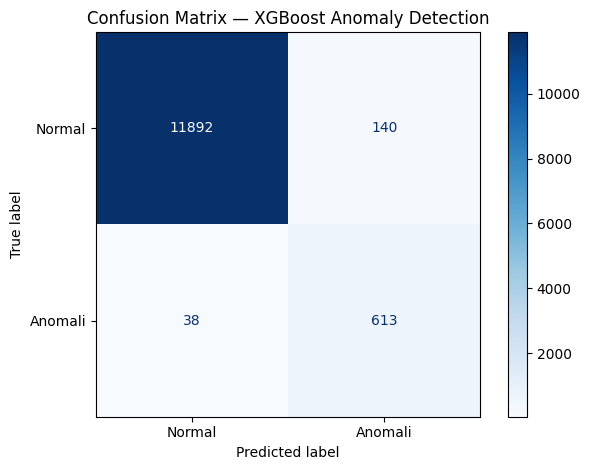

In [9]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali']).plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost Anomaly Detection')
plt.tight_layout()
plt.show()


cell 10 SHAP

c:\Users\fuadf\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


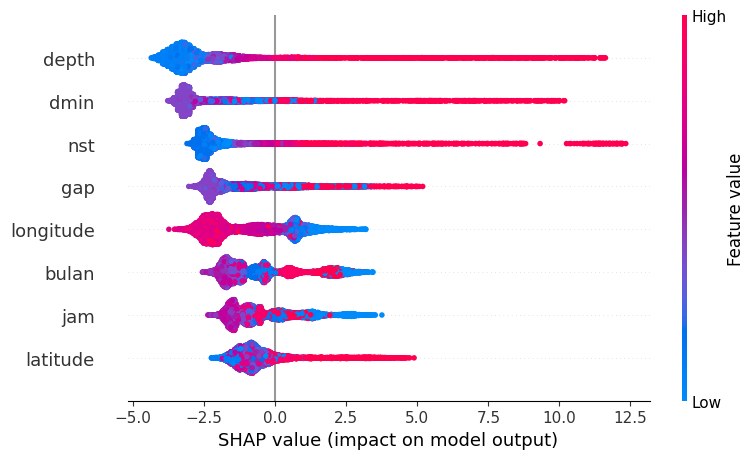

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=fitur)


cell 11 simpan model

In [11]:
joblib.dump(model, '../model_anomali.pkl')
joblib.dump(scaler, '../scaler_anomali.pkl')
print("Model berhasil disimpan")


Model berhasil disimpan


Contamination

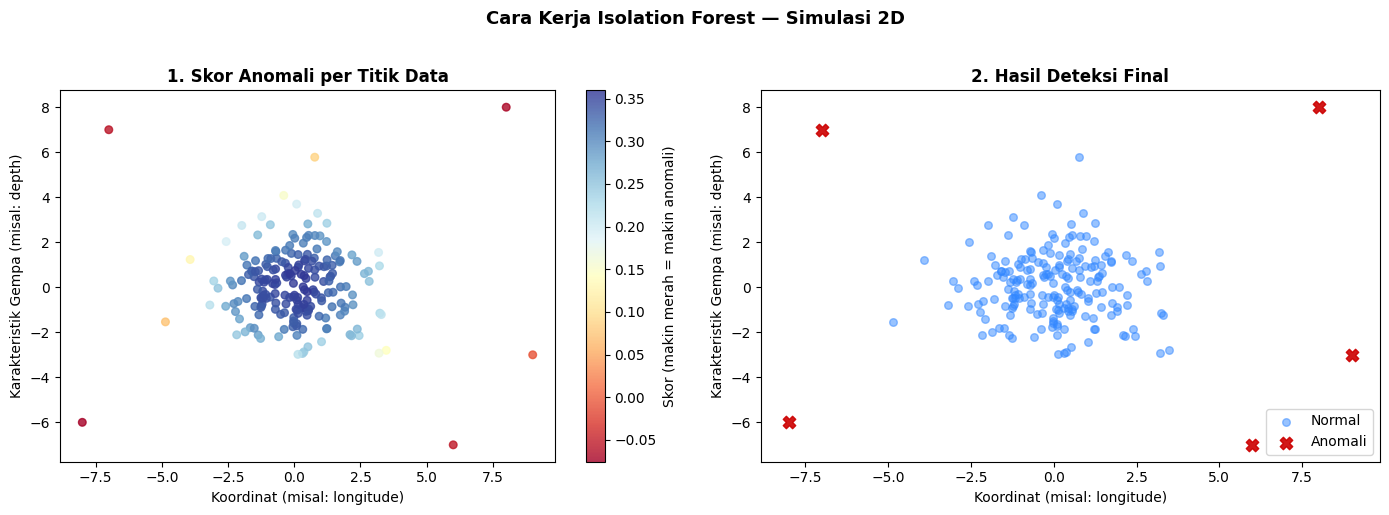

Disimpan: visualisasi_IF.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Simulasi sederhana 2D untuk visualisasi cara kerja IF
np.random.seed(42)

# Buat data normal (kerumunan) dan anomali (titik terpencil)
normal  = np.random.randn(200, 2) * 1.5          # 200 titik normal, berkumpul
anomali = np.array([[8, 8], [-7, 7], [6, -7],    # titik anomali, terpencil
                    [-8, -6], [9, -3]])

data = np.vstack([normal, anomali])

# Fit Isolation Forest
from sklearn.ensemble import IsolationForest
iso_viz = IsolationForest(contamination=0.02, random_state=42)
iso_viz.fit(data)
pred = iso_viz.predict(data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Skor anomali (proses IF) ---
ax = axes[0]
scores = iso_viz.decision_function(data)
scatter = ax.scatter(data[:, 0], data[:, 1],
                     c=scores, cmap='RdYlBu', s=30, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Skor (makin merah = makin anomali)')
ax.set_title('1. Skor Anomali per Titik Data', fontweight='bold')
ax.set_xlabel('Koordinat (misal: longitude)')
ax.set_ylabel('Karakteristik Gempa (misal: depth)')

# --- Plot 2: Hasil deteksi final ---
ax = axes[1]
ax.scatter(data[pred==1, 0],  data[pred==1, 1],
           c='#3388ff', alpha=0.5, label='Normal', s=30)
ax.scatter(data[pred==-1, 0], data[pred==-1, 1],
           c='#cc0000', alpha=0.9, label='Anomali', s=80, marker='X')
ax.set_title('2. Hasil Deteksi Final', fontweight='bold')
ax.legend()
ax.set_xlabel('Koordinat (misal: longitude)')
ax.set_ylabel('Karakteristik Gempa (misal: depth)')


plt.suptitle('Cara Kerja Isolation Forest — Simulasi 2D', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visualisasi_IF.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: visualisasi_IF.png")


Validasi BMKG

In [16]:
# Gabungkan label IF dengan df asli (yang punya kolom mag)
import pandas as pd
import numpy as np

# Gabungkan y_train dan y_test kembali sesuai index
y_all = np.concatenate([y_train, y_test])
idx_all = np.concatenate([X_train.index, X_test.index])

df_validasi = df.loc[idx_all].copy()
df_validasi['anomaly_label'] = y_all

# Cek hasilnya
print(df_validasi[['mag', 'anomaly_label']].head(10))
print("\nDistribusi label:")
print(df_validasi['anomaly_label'].value_counts())


   mag  anomaly_label
0  5.1              0
1  4.8              0
2  4.2              0
3  5.4              0
4  5.0              0
5  5.1              0
6  4.9              0
7  4.9              0
8  4.5              0
9  4.9              0

Distribusi label:
anomaly_label
0    60225
1     3188
Name: count, dtype: int64


Validasi BMKG ke-2

In [17]:
# VALIDASI: Apakah gempa M≥5 lebih sering terdeteksi anomali?
print("=" * 50)
print("VALIDASI LABEL IF vs MAGNITUDE")
print("=" * 50)

# Bagi berdasarkan threshold M≥5
gempa_besar = df_validasi[df_validasi['mag'] >= 5.0]
gempa_kecil = df_validasi[df_validasi['mag'] < 5.0]

pct_besar = gempa_besar['anomaly_label'].mean() * 100
pct_kecil = gempa_kecil['anomaly_label'].mean() * 100

print(f"\nGempa M≥5  : {len(gempa_besar):,} gempa → {pct_besar:.2f}% terdeteksi anomali")
print(f"Gempa M<5  : {len(gempa_kecil):,} gempa → {pct_kecil:.2f}% terdeteksi anomali")
print(f"\nRasio      : gempa besar {pct_besar/pct_kecil:.2f}x lebih sering anomali")

# Breakdown per rentang magnitude
print("\n--- Breakdown per rentang magnitude ---")
bins = [0, 3, 4, 5, 6, 7, 10]
labels_bin = ['<3', '3-4', '4-5', '5-6', '6-7', '≥7']
df_validasi['mag_group'] = pd.cut(df_validasi['mag'], bins=bins, labels=labels_bin)
tabel = df_validasi.groupby('mag_group', observed=True)['anomaly_label'].agg(['sum','count','mean'])
tabel.columns = ['Jumlah Anomali', 'Total Gempa', 'Persentase Anomali']
tabel['Persentase Anomali'] = (tabel['Persentase Anomali'] * 100).round(2)
print(tabel)


VALIDASI LABEL IF vs MAGNITUDE

Gempa M≥5  : 9,863 gempa → 5.05% terdeteksi anomali
Gempa M<5  : 53,550 gempa → 5.02% terdeteksi anomali

Rasio      : gempa besar 1.01x lebih sering anomali

--- Breakdown per rentang magnitude ---
           Jumlah Anomali  Total Gempa  Persentase Anomali
mag_group                                                 
<3                      0           22                0.00
3-4                   379         7325                5.17
4-5                  2401        48529                4.95
5-6                   379         6929                5.47
6-7                    26          542                4.80
≥7                      3           66                4.55


Analisis gempa anomali vs normal

In [18]:
# ANALISIS: Profil fitur rata-rata Anomali vs Normal
print("=" * 55)
print("PROFIL FITUR: ANOMALI vs NORMAL")
print("=" * 55)

fitur = ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'nst', 'bulan', 'jam']

anomali = df_validasi[df_validasi['anomaly_label'] == 1]
normal  = df_validasi[df_validasi['anomaly_label'] == 0]

profil = pd.DataFrame({
    'Normal (rata-rata)'  : normal[fitur].mean(),
    'Anomali (rata-rata)' : anomali[fitur].mean(),
})
profil['Selisih %'] = ((profil['Anomali (rata-rata)'] - profil['Normal (rata-rata)']) 
                        / profil['Normal (rata-rata)'] * 100).round(1)

print(profil.round(3))


PROFIL FITUR: ANOMALI vs NORMAL
           Normal (rata-rata)  Anomali (rata-rata)  Selisih %
latitude               -2.564               -2.603        1.5
longitude             121.630              121.566       -0.1
depth                  81.336               83.828        3.1
gap                   107.789              107.816        0.0
dmin                    2.156                2.140       -0.7
nst                    30.774               31.407        2.1
bulan                   6.554                6.544       -0.1
jam                    11.867               11.782       -0.7


SHAP Analysis

In [19]:
import shap
import matplotlib.pyplot as plt

print("Menghitung SHAP values...")
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test_scaled)

# Jika output shap_values adalah list (binary classification), ambil index 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

feature_names = ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'nst', 'bulan', 'jam']

print("Shape shap_values:", sv.shape)
print("Selesai.")


Menghitung SHAP values...
Shape shap_values: (12683, 8)
Selesai.


SHAP Summary Plot

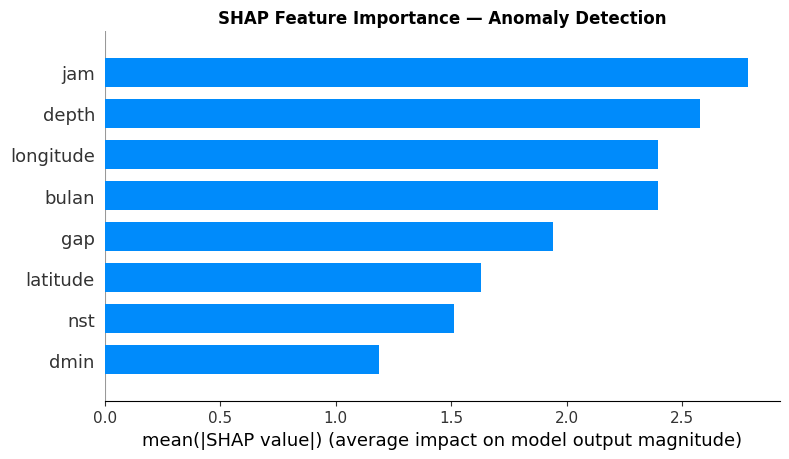

Disimpan: shap_importance.png


In [20]:
# SHAP Summary Plot — fitur paling berpengaruh
plt.figure()
shap.summary_plot(sv, X_test_scaled, 
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Anomaly Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: shap_importance.png")


SHAP Beeswarm Plot

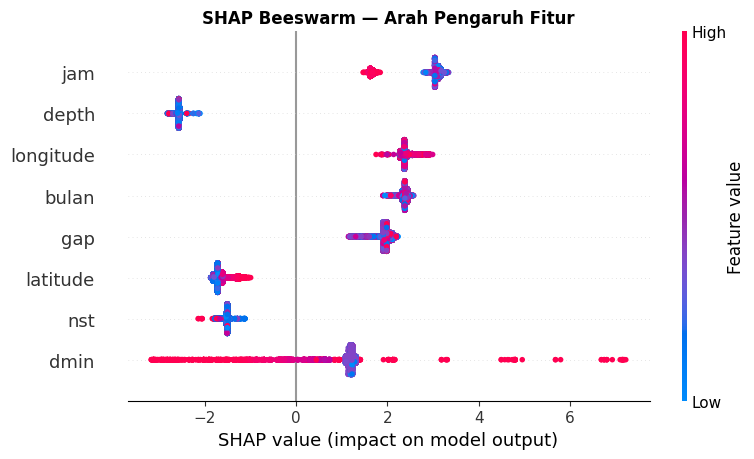

Disimpan: shap_beeswarm.png


In [21]:
# SHAP Beeswarm Plot — arah pengaruh tiap fitur
plt.figure()
shap.summary_plot(sv, X_test_scaled,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Beeswarm — Arah Pengaruh Fitur', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: shap_beeswarm.png")


In [22]:
# Investigasi: jam berapa yang paling sering jadi anomali?
print("Distribusi jam pada gempa ANOMALI:")
print(anomali['jam'].value_counts().sort_index())
print("\nDistribusi jam pada gempa NORMAL (sampel):")
print(normal['jam'].value_counts().sort_index())


Distribusi jam pada gempa ANOMALI:
jam
0     142
1     151
2     144
3     125
4     114
5     118
6     108
7     113
8     110
9     113
10    119
11    146
12    115
13    138
14    134
15    141
16    152
17    147
18    156
19    130
20    188
21    140
22    118
23    126
Name: count, dtype: int64

Distribusi jam pada gempa NORMAL (sampel):
jam
0     2485
1     2456
2     2293
3     2311
4     2419
5     2278
6     2238
7     2208
8     2290
9     2399
10    2374
11    2408
12    2470
13    2625
14    2634
15    2736
16    2884
17    2793
18    2792
19    2714
20    2712
21    2687
22    2585
23    2434
Name: count, dtype: int64
